**Two embeddings, one comparison.**
1. **Nucleotide-Transformer (50M)** — a small DNA language model, mean-pooled to one vector per read.
2. **k-mer composition (4-mer)** — a no-download baseline.

## 1. Config

In [ ]:
POOL_GLOB   = "data/*.fasta*"     
PANEL_FASTA = "references/panel.fasta"   
CONTIG_TSV  = "results/detections_by_contig.tsv" 

NT_MODEL    = "InstaDeepAI/nucleotide-transformer-v2-50m-multi-species"
USE_NT      = True     

# Sampling: keep it light and BALANCED so the dominant coronaviruses don't drown rhinovirus.
MAX_READS_PER_POOL = 4000   
MAX_PER_GROUP      = 300   
MIN_READ_LEN       = 300   
MAX_TOKENS         = 1000  
KEEP_UNMAPPED      = False  
RANDOM_STATE       = 0
OUTDIR             = "track_b_out"

## 2. Helpers and read loading

In [7]:
import os, glob, gzip, random
from itertools import product
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import mappy as mp

random.seed(RANDOM_STATE); np.random.seed(RANDOM_STATE)
os.makedirs(OUTDIR, exist_ok=True)

def read_fasta(path):
    """Yield (name, sequence) from a .fasta or .fasta.gz file."""
    op = gzip.open if str(path).endswith(".gz") else open
    name, chunks = None, []
    with op(path, "rt") as fh:
        for line in fh:
            line = line.rstrip()
            if not line:
                continue
            if line[0] == ">":
                if name is not None:
                    yield name, "".join(chunks)
                name, chunks = line[1:].split()[0], []
            else:
                chunks.append(line.upper())
    if name is not None:
        yield name, "".join(chunks)

In [8]:
pool_files = sorted(glob.glob(POOL_GLOB))
assert pool_files, f"No pool FASTAs matched {POOL_GLOB!r} -- fix POOL_GLOB."
print(f"{len(pool_files)} pool files")

reads = []  # (read_id, pool, seq)
for pf in pool_files:
    pool = os.path.basename(pf).split(".")[0]
    n = 0
    for rid, seq in read_fasta(pf):
        if len(seq) < MIN_READ_LEN:
            continue
        reads.append((rid, pool, seq)); n += 1
        if n >= MAX_READS_PER_POOL:
            break
print(f"loaded {len(reads)} reads (>= {MIN_READ_LEN} bp) from {len(pool_files)} pools")

12 pool files
loaded 38162 reads (>= 300 bp) from 12 pools


## 3. Label every read against the Part 2 panel

In [9]:
# reference id -> clean virus group, from your Part 2 table
cdf = pd.read_csv(CONTIG_TSV, sep="\t")
ref2group   = dict(zip(cdf["taxon"], cdf["taxon_group"]))
groups_known = set(cdf["taxon_group"])
print("known virus groups:", sorted(groups_known))

aligner = mp.Aligner(PANEL_FASTA, preset="map-ont")
assert aligner, f"Failed to load {PANEL_FASTA}"

def label_read(seq, min_mapq=2):
    best = None
    for h in aligner.map(seq):
        if best is None or h.mlen > best.mlen:
            best = h
    if best is None or best.mapq < min_mapq:
        return "unmapped", np.nan
    grp = ref2group.get(best.ctg)
    if grp is None:                       # fallback: parse "Group__Accession"
        pref = best.ctg.split("__")[0]
        grp = pref if pref in groups_known else best.ctg
    ident = best.mlen / max(best.blen, 1) # rough alignment identity
    return grp, ident

labels, idents = [], []
for rid, pool, seq in reads:
    g, idn = label_read(seq)
    labels.append(g); idents.append(idn)

lab_df = pd.DataFrame({
    "read_id":      [r[0] for r in reads],
    "pool":         [r[1] for r in reads],
    "seq":          [r[2] for r in reads],
    "taxon":        labels,
    "aln_identity": idents,
})
print(lab_df["taxon"].value_counts())

known virus groups: ['HCoV_229E', 'HCoV_HKU1', 'HCoV_NL63', 'HCoV_OC43', 'HMPV', 'Influenza_C', 'RSV', 'Rhinovirus_A', 'Rhinovirus_B', 'Rhinovirus_C', 'SARS_CoV_2']
HCoV_HKU1       10265
unmapped         8084
HCoV_229E        7940
SARS_CoV_2       4366
HCoV_NL63        4338
Rhinovirus_A     1810
Rhinovirus_C     1126
HMPV              158
HCoV_OC43          42
RSV                19
Rhinovirus_B        9
Influenza_C         5
Name: taxon, dtype: int64


## 4. Balance the read set

Cap reads per virus group so abundant coronaviruses don't dominate the embedding space and so rhinovirus/hMPV get a fair showing.

In [ ]:
df = lab_df if KEEP_UNMAPPED else lab_df[lab_df.taxon != "unmapped"].copy()
parts = [d.sample(min(len(d), MAX_PER_GROUP), random_state=RANDOM_STATE)
         for _, d in df.groupby("taxon")]
df = pd.concat(parts).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

seqs = df.seq.tolist()
y    = df.taxon.values
print(f"{len(df)} reads after balancing across {df.taxon.nunique()} groups")
print(df.taxon.value_counts())

2033 reads after balancing across 11 groups
SARS_CoV_2      300
HCoV_229E       300
Rhinovirus_A    300
HCoV_HKU1       300
HCoV_NL63       300
Rhinovirus_C    300
HMPV            158
HCoV_OC43        42
RSV              19
Rhinovirus_B      9
Influenza_C       5
Name: taxon, dtype: int64


## 5. Embedding A — k-mer composition (baseline, no download)

In [11]:
def kmer_vectors(seqs, k=4):
    kmers = ["".join(p) for p in product("ACGT", repeat=k)]
    idx   = {km: i for i, km in enumerate(kmers)}
    M = np.zeros((len(seqs), len(kmers)), dtype=np.float32)
    for r, s in enumerate(seqs):
        for i in range(len(s) - k + 1):
            j = idx.get(s[i:i+k])
            if j is not None:
                M[r, j] += 1
        t = M[r].sum()
        if t > 0:
            M[r] /= t          # frequency, not raw count
    return M

Xkmer = kmer_vectors(seqs, k=4)
print("k-mer embedding:", Xkmer.shape)

k-mer embedding: (2033, 256)


## 6. Embedding B — Nucleotide-Transformer (50M)

In [12]:
Xnt = None
if USE_NT:
    try:
        import torch
        from transformers import AutoTokenizer, AutoModelForMaskedLM

        dev = ("mps"  if torch.backends.mps.is_available()
               else "cuda" if torch.cuda.is_available() else "cpu")
        print("device:", dev, "| loading", NT_MODEL)
        tok = AutoTokenizer.from_pretrained(NT_MODEL, trust_remote_code=True)
        mdl = AutoModelForMaskedLM.from_pretrained(
            NT_MODEL, trust_remote_code=True, output_hidden_states=True
        ).to(dev).eval()

        def nt_embed(seqs, batch=8, max_tokens=MAX_TOKENS):
            out_vecs = []
            for i in range(0, len(seqs), batch):
                enc = tok(seqs[i:i+batch], return_tensors="pt", padding=True,
                          truncation=True, max_length=max_tokens).to(dev)
                with torch.no_grad():
                    out = mdl(input_ids=enc["input_ids"],
                              attention_mask=enc["attention_mask"])
                h = out.hidden_states[-1]                  # (B, T, H)
                m = enc["attention_mask"].unsqueeze(-1)    # (B, T, 1)
                pooled = (h * m).sum(1) / m.sum(1).clamp(min=1)
                out_vecs.append(pooled.float().cpu().numpy())
                print(f"  embedded {min(i+batch, len(seqs))}/{len(seqs)}", end="\r")
            return np.vstack(out_vecs)

        Xnt = nt_embed(seqs)
        print("\nNT embedding:", Xnt.shape)
    except Exception as e:
        print("NT embedding unavailable -> continuing with k-mer only.\n  reason:", repr(e))
        Xnt = None

device: mps | loading InstaDeepAI/nucleotide-transformer-v2-50m-multi-species
NT embedding unavailable -> continuing with k-mer only.
  reason: OSError("We couldn't connect to 'https://huggingface.co' to load this model, couldn't find it in the cached files and it looks like InstaDeepAI/nucleotide-transformer-v2-50m-multi-species is not the path to a directory containing a config.json file.\nCheckout your internet connection or see how to run the library in offline mode at 'https://huggingface.co/docs/transformers/installation#offline-mode'.")


## 7. Cluster and score against the Part 2 taxonomy

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, HDBSCAN
from sklearn.metrics import (adjusted_rand_score, adjusted_mutual_info_score,
                             homogeneity_completeness_v_measure)
import umap

def analyze(X, y, name, n_taxa):
    Xs  = StandardScaler().fit_transform(X)
    npc = min(30, Xs.shape[1] - 1, Xs.shape[0] - 1)
    Xp  = PCA(n_components=npc, random_state=RANDOM_STATE).fit_transform(Xs)
    emb = umap.UMAP(n_neighbors=15, min_dist=0.1,
                    random_state=RANDOM_STATE).fit_transform(Xp)
    km  = KMeans(n_clusters=n_taxa, n_init=10,
                 random_state=RANDOM_STATE).fit_predict(Xp)
    hd  = HDBSCAN(min_cluster_size=max(15, len(y)//50)).fit_predict(Xp)
    rows = []
    for cname, pred in [("KMeans", km), ("HDBSCAN", hd)]:
        ari = adjusted_rand_score(y, pred)
        ami = adjusted_mutual_info_score(y, pred)
        h, c, v = homogeneity_completeness_v_measure(y, pred)
        nc = len(set(pred)) - (1 if -1 in pred else 0)
        rows.append(dict(embedding=name, clusterer=cname, ARI=round(ari,3),
                         AMI=round(ami,3), homogeneity=round(h,3),
                         completeness=round(c,3), n_clusters=nc,
                         noise=int((pred == -1).sum())))
    return emb, km, hd, pd.DataFrame(rows)

n_taxa  = len(set(y))
results = []
emb_kmer, km_k, hd_k, r_k = analyze(Xkmer, y, "k-mer(4)", n_taxa); results.append(r_k)
if Xnt is not None:
    emb_nt, km_n, hd_n, r_n = analyze(Xnt, y, "NT-50M", n_taxa); results.append(r_n)

score_table = pd.concat(results, ignore_index=True)
score_table.to_csv(f"{OUTDIR}/cluster_scores.tsv", sep="\t", index=False)
score_table

/opt/homebrew/Caskroom/miniforge/base/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #273: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


,embedding,clusterer,ARI,AMI,homogeneity,completeness,n_clusters,noise
0,k-mer(4),KMeans,0.555,0.705,0.733,0.685,11,0
1,k-mer(4),HDBSCAN,0.280,0.597,0.595,0.609,11,824


## 8. The figure: UMAP coloured by taxonomy vs by cluster

Left: reads coloured by their Part 2 virus label. Right: the same points coloured by unsupervised HDBSCAN cluster.

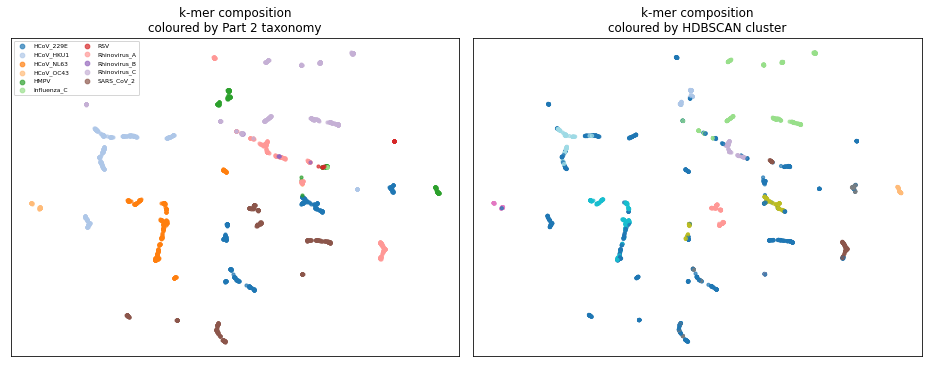

In [18]:
def plot_pair(emb, y, clust, title):
    fig, ax = plt.subplots(1, 2, figsize=(13, 5.2))
    taxa = sorted(set(y)); cmap = plt.cm.tab20
    for i, t in enumerate(taxa):
        m = y == t
        ax[0].scatter(emb[m,0], emb[m,1], s=10, alpha=.7, color=cmap(i % 20), label=t)
    ax[0].set_title(f"{title}\ncoloured by Part 2 taxonomy")
    ax[0].legend(fontsize=6, markerscale=1.5, ncol=2, loc="best")
    ax[1].scatter(emb[:,0], emb[:,1], s=10, alpha=.7, c=clust, cmap="tab20")
    ax[1].set_title(f"{title}\ncoloured by HDBSCAN cluster")
    for a in ax: a.set_xticks([]); a.set_yticks([])
    plt.tight_layout(); return fig

if Xnt is not None:
    fig = plot_pair(emb_nt, y, hd_n, "Nucleotide-Transformer 50M")
else:
    fig = plot_pair(emb_kmer, y, hd_k, "k-mer composition")
fig.savefig(f"{OUTDIR}/umap_taxonomy_vs_clusters.png", dpi=500, bbox_inches="tight")
plt.show()

## 9. Contingency: which taxa land in which clusters

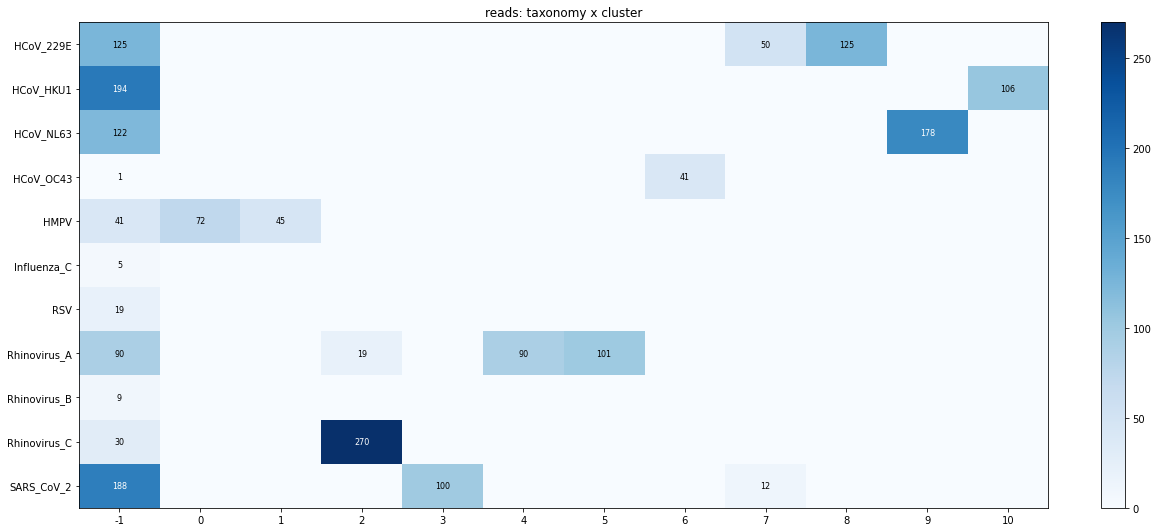

cluster,-1,0,1,2,3,4,5,6,7,8,9,10
taxon (Part 2),,,,,,,,,,,,
HCoV_229E,125,0,0,0,0,0,0,0,50,125,0,0
HCoV_HKU1,194,0,0,0,0,0,0,0,0,0,0,106
HCoV_NL63,122,0,0,0,0,0,0,0,0,0,178,0
HCoV_OC43,1,0,0,0,0,0,0,41,0,0,0,0
HMPV,41,72,45,0,0,0,0,0,0,0,0,0
Influenza_C,5,0,0,0,0,0,0,0,0,0,0,0
RSV,19,0,0,0,0,0,0,0,0,0,0,0
Rhinovirus_A,90,0,0,19,0,90,101,0,0,0,0,0
Rhinovirus_B,9,0,0,0,0,0,0,0,0,0,0,0


In [17]:
pred = hd_n if Xnt is not None else hd_k
ct = pd.crosstab(pd.Series(y, name="taxon (Part 2)"),
                 pd.Series(pred, name="cluster"))

fig, ax = plt.subplots(figsize=(1.1*ct.shape[1] + 3, 0.5*ct.shape[0] + 2))
im = ax.imshow(ct.values, aspect="auto", cmap="Blues")
ax.set_xticks(range(ct.shape[1])); ax.set_xticklabels(ct.columns)
ax.set_yticks(range(ct.shape[0])); ax.set_yticklabels(ct.index)
mx = ct.values.max()
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        v = ct.values[i, j]
        if v:
            ax.text(j, i, v, ha="center", va="center", fontsize=8,
                    color="white" if v > mx/2 else "black")
ax.set_title("reads: taxonomy x cluster")
plt.colorbar(im, fraction=.03); plt.tight_layout()
fig.savefig(f"{OUTDIR}/contingency.png", dpi=130, bbox_inches="tight")
plt.show()
ct

## 10. Read the result

Fill these in from your own numbers — they become the write-up.

- **Do clusters match taxonomy?** Quote ARI/AMI from the score table. ARI near 1 = the embedding recovered the Part 2 taxonomy with no labels; near 0 = it didn't.
- **k-mer vs language model.** If NT's ARI ≥ the k-mer ARI, the learned model is at least matching simple composition; a clear gap is worth a sentence. If they're close, that itself is the finding — for these viruses, composition alone carries most of the taxonomic signal.
- **The rhinovirus story (the headline).** In Part 2 rhinoviruses rated LOW *only* because they align at ~0.65–0.83 identity to a single RefSeq prototype. Here, do their reads form a tight, separate cluster? If yes, the embedding independently confirms they're a real, coherent group — alignment-divergent, not doubtful. If `Rhinovirus_A/B/C` land in one cluster, that matches their shared composition despite spanning 160+ types.
- **Off-panel / divergent reads.** Re-run with `KEEP_UNMAPPED = True`: if `unmapped` reads form their own cluster rather than scattering, that's the pathogen-agnostic angle — clustering surfaces structure that the 14-virus alignment panel can't see.

Outputs saved to `track_b_out/`: `cluster_scores.tsv`, `umap_taxonomy_vs_clusters.png`, `contingency.png`.